<a href="https://colab.research.google.com/github/ArielaLevkov/ImageProcessing_TA/blob/main/recitations/12_ImageProcessingRecitation_Fourier2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import requests
from io import BytesIO
from ipywidgets import interactive
import matplotlib.pyplot as plt
import plotly.express as px
import PIL
from numpy.fft import fft2, ifft2, fftshift, ifftshift
import numpy as np
π = np.pi

In [ ]:
GITHUB_PATH = 'https://raw.githubusercontent.com/ArielaLevkov/ImageProcessing_TA/main/images/'

def read_file(file_name:str, file_path:str=GITHUB_PATH) -> np.ndarray:
    '''
    Accept an image file name (defaulty located in GitHub) and return the image
    in a numpy array.

    Args:
        file_name: the file name
        file_path: the file path.. Default value is Doron's Github repo.

    Returns:
        the image converted into a Numpy array.
    '''
    file_path = os.path.join(file_path, file_name)
    response = requests.get(file_path)
    fp = BytesIO(response.content)

    img_pil = PIL.Image.open(fp)
    return np.array(img_pil, dtype='int16')

In [ ]:
def plot_axis(splot, x, xlabel, y, ylabel, xlim=False, ylim=False):
    splot.plot(x, y)
    if splot == plt:
        splot.xlabel(xlabel)
        splot.ylabel(ylabel)
        if xlim:
            plt.xlim(xlim)
        if ylim:
            plt.ylim(ylim)
    else:
        splot.set_xlabel(xlabel)
        splot.set_ylabel(ylabel)
        if xlim:
            splot.set_xlim(xlim)
        if ylim:
            splot.set_ylim(ylim)
    splot.axhline(y=0, color='k')
    splot.axvline(x=0, color='k')
    splot.grid()

<div dir="rtl">

# 12.1 ייצוג פולרי וקרטזי:
<dir>

<div dir="rtl">

לכל תדר ספציפי קיימות שתי דרגות חופש:

אמפליטודה (A) – עוצמת הרכיב בתדר זה

פאזה (φ) – ההיסט הזוויתי של הרכיב

ניתן לייצג את המידע הזה בשתי דרכים שקולות:

ייצוג פולרי – באמצעות אמפליטודה ופאזה: $(A,\phi)$

ייצוג קרטזי – באמצעות שני רכיבים ממשיים: $(x,y)$.

הייצוג הקרטזי שקול לייצוג של מספר מרוכב:  $z=x+iy$.  $(i=\sqrt{-1})$.

כלומר, לכל תדר מתאים מקדם מרוכב, אשר מכיל בו־זמנית גם את האמפליטודה וגם את הפאזה של אותו תדר.

באמצעות נוסחת אוילר: $e^{i\phi}=\cos\phi + i \sin \phi$

ניתן לעבור בין שני הייצוגים:

* הייצוג הפולרי: $A=|z| = \sqrt{x^2+y^2}$.
* הייצוג הקרטזי: $z=A(cos\phi + i \sin \phi)$.

שני הייצוגים מתארים את אותו מקדם תדר, ואין ביניהם הבדל מתמטי – רק הבדל בצורת ההצגה.


<dir>

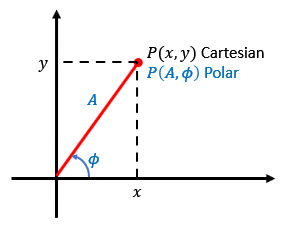

<div dir="rtl">


<dir>

<div dir="rtl">

## 12.2 תדר נייקוסט:

תדר נייקוויסט מוגדר כחצי מקצב הדגימה: $f_N=f_s/2$.

כדי שניתן יהיה לשחזר את האות מן הדגימות שלו, קצב הדגימה חייב להיות לפחות פי שניים מהתדר הגבוה ביותר באות: $f_s>=2f_{max}$.

תדרים הגבוהים מתדר נייקוויסט אינם ניתנים לייצוג חד־חד־ערכי לאחר הדגימה.

<dir>

<div dir="rtl">

## 12.3 דגימה:

במקרים מעשיים רבים אין בידינו ביטוי אנליטי רציף של האות, אלא רק ערכים שלו בנקודות בדידות. במקום פונקציה רציפה לדוגמה $f(t)=\sin(t)$, נדגום אותה בנקודות זמן בדידות $(t=1,2,\dots,n)$.

תהליך זה נקרא דגימה (sampling).
<dir>

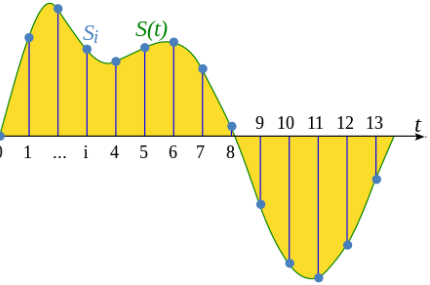

<div dir="rtl">

## 11.4 Aliasing

אם קצב הדגימה נמוך מתנאי נייקויסט:

 אזי, רכיבי תדר גבוהים אינם ניתנים לייצוג נכון לאחר הדגימה.

כתוצאה מכך, רכיבי תדר שמעל תדר נייקוויסט מתקפלים ומופיעים כתדרים נמוכים יותר בספקטרום הדגום.

תופעה זו נקראת aliasing.

<dir>

<div dir="rtl">


לדוגמה:

במקום לדגום את האות פעמיים בכל מחזור, אנו דוגמים אותו אחת לכל שלושה רבעים של מחזור.

כלומר, מרווח הדגימה גדול יותר, וקצב הדגימה נמוך מן הנדרש לפי תנאי נייקוויסט.

<dir>

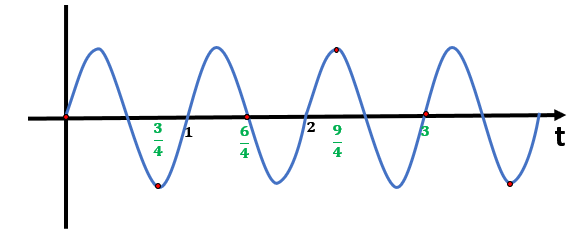

<div dir="rtl">

כתוצאה מכך, הסיגנל המתקבל לאחר הדגימה משתקף סביב תדר נייקוויסט.

תופעה זו נקראת aliasing.

<dir>

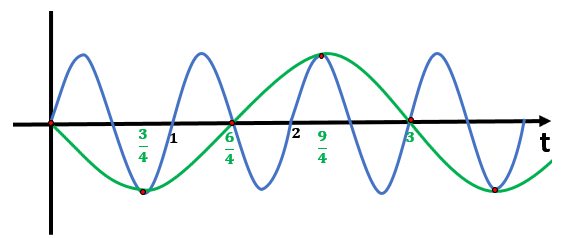

<div dir="rtl">

יש להבחין בין שלושה מושגים שונים:

Fourier Transform (FT) – התמרת פורייה של אות רציף.

Discrete Fourier Transform (DFT) – התמרת פורייה של אות בדיד, המוגדר על מספר סופי של דגימות.

Fast Fourier Transform (FFT) – אלגוריתם יעיל לחישוב ה־DFT.

<dir>

<div dir="rtl">

## 11.4 התמרת פוריה 2D:

במקרה של תמונה, האות אינו חד ממדי אלא דו ממדי, ותלוי בשני משתנים מרחביים $x,y$

לכן משתמשים בהתמרת פורייה דו ממדית, אשר מפרקת את התמונה לרכיבי תדר מרחביים בשני כיוונים.

התמרת פורייה הדו ממדית ממפה פונקציה במרחב $(x,y)$ למישור התדר $(u,v)$  
כאשר $u,v$ מייצגים תדרים מרחביים בכיוונים האופקי והאנכי.

<dir>

<div dir="rtl">

תמונה דו־ממדית $B(x,y)$ ניתנת לייצוג באמצעות הבסיס הסטנדרטי הדו־ממדי, כצירוף לינארי של רכיבי בסיס.

<dir>

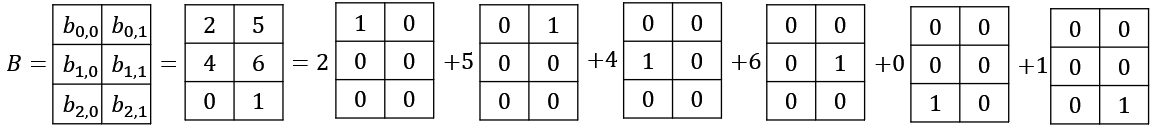



<div dir="rtl">

לאחר ביצוע התמרת DFT, התמונה מיוצגת בתחום התדרים.

בייצוג זה, כל נקודה מתארת רכיב תדר מרחבי מסוים בתמונה.

<dir>

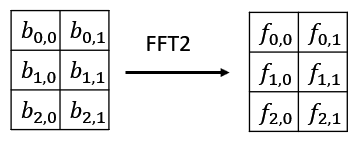

<div dir="rtl">

לאחר התמרת DFT ניתן לייצג את התמונה $B$ כצירוף לינארי של פונקציות בסיס בתדרים שונים:

$B=f_{0,0}\cdot F_{0,0}+f_{0,1}\cdot F_{0,1}+f_{1,0}\cdot F_{1,0}+f_{1,1}\cdot F_{1,1}+f_{2,0}\cdot F_{2,0}+f_{2,1}\cdot F_{2,1}$

כאשר:

$F_{0,0}$ - פונקציית הDC, המתאימה לתדר 0 בציר $x$ ולתדר 0 בציר $y$
זוהי פונקציה קבועה, כלומר מטריצה שבה כל הערכים זהים.

$f_{0,0}$ - המקדם הסקלרי של $F_{0,0}$ ומייצג את ערך האפור הממוצע של התמונה.

$f_{0,1}$ - המקדם של פונקציית בסיס בעלת מחזור אחד בציר האופקי ואפס מחזורים בציר האנכי
(כלומר, פונקציה שמשתנה לאורך $x$ וקבועה לאורך $y$).

<dir>

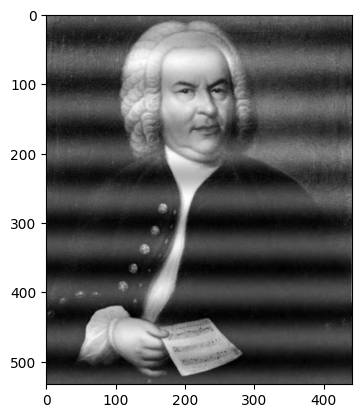

In [ ]:
img1 = read_file(file_name='fftDemo1.tiff') / 255
plt.imshow(img1, cmap='gray');

In [ ]:
f1 = fft2(img1)

<div dir="rtl">

בדיקת רכיב DC תדר האפס:
<dir>

In [ ]:
print(int(img1.mean() * 255), int(255*f1[0,0].real/img1.size))

79 79


<div dir="rtl">

**שאלה:** למה מקבלים תמונה כמעט שחורה?

**תשובה:** כי רכיב הDC $f1[0,0]$ גדול משמעותית ושאר הערכים קטנים יחסית. הצגה ליניארית נמחצת ע"י הערך הדומיננטי.
<dir>

In [ ]:
fig = px.imshow(f1.real, color_continuous_scale='gray')
fig.update_layout(coloraxis_showscale=False)

<div dir="rtl">

לכן נחשב את האמפליטודה ונציג בסקלה לוגריתמית.
<dir>

In [ ]:
mag = abs(f1)  # Calculate the complex magnitude
mag = np.log1p(mag) # Logarithm scaling
fig = px.imshow(mag.real, color_continuous_scale='gray')
fig.update_layout(coloraxis_showscale=False)